# Aula 8 · Parte 1 — Laboratório comparativo de classificação

**Aprendizado de Máquina (PEPAPRM)** · IFSP Câmpus Presidente Epitácio

Nesta aula os cinco classificadores vistos anteriormente — **k-NN, regressão logística, árvore de decisão, Naive Bayes e SVM** — competem no **mesmo problema real**: as solicitações de empréstimo (valores ausentes, uma coluna categórica e outliers em renda).

**Regra do jogo:** mesmo pré-processamento, mesmo treino e mesmo teste para todos. Assim, qualquer diferença de desempenho vem do **algoritmo**, e não de como os dados foram preparados.

**Roteiro:** 1) dados · 2) baseline · 3) comparação · 4) matriz de confusão · 5) efeito da escala · 6) hiperparâmetros · 7) o problema de um único sorteio.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
SEMENTE = 42
pd.set_option("display.width", 100)

In [2]:
def gerar_dados_emprestimo(n=450, semente=42):
    """Mesmo dataset das aulas de preparacao de dados: solicitacoes de
    emprestimo, com valores ausentes, uma coluna categorica e outliers."""
    rng = np.random.default_rng(semente)

    idade = rng.normal(38, 12, n).clip(18, 75).round().astype(float)
    score_credito = rng.normal(650, 80, n).clip(300, 850).round().astype(float)
    tempo_emprego = rng.normal(7, 5, n).clip(0, 35).round().astype(float)

    renda = rng.lognormal(mean=8.15, sigma=0.45, size=n)
    idx_outlier = rng.choice(n, size=5, replace=False)
    renda[idx_outlier] *= rng.uniform(6, 10, size=5)
    renda = renda.round(2)

    cidades = np.array(["SP", "RJ", "MG", "Outra"])
    cidade = rng.choice(cidades, size=n, p=[0.42, 0.23, 0.15, 0.20])

    renda_c = np.clip(renda, None, np.percentile(renda, 95))
    z = (
        0.05 * (score_credito - 650)
        + 0.0008 * (renda_c - renda_c.mean())
        + 0.12 * (tempo_emprego - 7)
        + rng.normal(0, 0.35, n)
    )
    prob_aprovado = 1 / (1 + np.exp(-z))
    aprovado = (rng.uniform(0, 1, n) < prob_aprovado).astype(int)

    df = pd.DataFrame({
        "idade": idade,
        "renda": renda,
        "tempo_emprego": tempo_emprego,
        "score_credito": score_credito,
        "cidade": cidade,
        "aprovado": aprovado,
    })

    mask_idade = rng.uniform(0, 1, n) < 0.08
    mask_renda = rng.uniform(0, 1, n) < 0.10
    mask_cidade = rng.uniform(0, 1, n) < 0.06
    df.loc[mask_idade, "idade"] = np.nan
    df.loc[mask_renda, "renda"] = np.nan
    df.loc[mask_cidade, "cidade"] = None
    return df


COL_NUM = ["idade", "renda", "tempo_emprego", "score_credito"]
COL_CAT = ["cidade"]


def montar_preprocessador(escalar=True):
    """Imputacao + (escala) nos numericos; imputacao + one-hot na categorica.
    Tudo dentro de um ColumnTransformer: as estatisticas (mediana, media,
    desvio, categorias) sao aprendidas SO no treino."""
    passos_num = [("imp", SimpleImputer(strategy="median"))]
    if escalar:
        passos_num.append(("esc", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(passos_num), COL_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), COL_CAT),
    ])



def criar_modelos():
    return {
        "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "Regressão Logística": LogisticRegression(max_iter=1000),
        "Árvore de Decisão (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=SEMENTE),
        "Naive Bayes (Gaussiano)": GaussianNB(),
        "SVM (kernel=rbf)": SVC(kernel="rbf", random_state=SEMENTE),
    }


def metricas(y_verd, y_prev):
    return {
        "acurácia": accuracy_score(y_verd, y_prev),
        "precisão": precision_score(y_verd, y_prev, zero_division=0),
        "recall": recall_score(y_verd, y_prev, zero_division=0),
        "f1": f1_score(y_verd, y_prev, zero_division=0),
    }

## 1. O problema e os dados

Problema de **classificação binária**: aprovar (1) ou negar (0) um empréstimo. Há valores ausentes em três colunas e uma coluna categórica (`cidade`), então os dados **não** podem ir direto para os algoritmos.

In [3]:
df = gerar_dados_emprestimo(n=450, semente=SEMENTE)
X = df.drop(columns="aprovado")
y = df["aprovado"]

print(f"Solicitações: {len(df)} | atributos: {X.shape[1]}")
print("\nValores ausentes por coluna:")
print(df.isna().sum().to_string())
print("\nProporção de cada classe:")
print(y.value_counts(normalize=True).round(3).to_string())
df.head()

Solicitações: 450 | atributos: 5

Valores ausentes por coluna:
idade            41
renda            42
tempo_emprego     0
score_credito     0
cidade           33
aprovado          0

Proporção de cada classe:
aprovado
0    0.52
1    0.48


,idade,renda,tempo_emprego,score_credito,cidade,aprovado
0,NaN,3090.86,9.0,640.0,Outra,0
1,26.0,4460.53,8.0,678.0,SP,1
2,47.0,1936.53,6.0,806.0,SP,1
3,49.0,4058.96,15.0,816.0,SP,1
4,18.0,8191.31,4.0,656.0,SP,1


As duas classes estão quase equilibradas (52% × 48%), então a acurácia é uma métrica razoável para começar.

## 2. O piso: um modelo que não aprende nada

O **baseline** sempre prevê a classe mais comum do treino. É o piso de qualquer comparação: um modelo que não o supera não aprendeu nada útil. O parâmetro `stratify=y` mantém a mesma proporção de aprovados em treino e teste.

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=SEMENTE, stratify=y
)
print(f"Treino: {len(X_treino)} linhas | Teste: {len(X_teste)} linhas")
print(f"Proporção de aprovados — treino: {y_treino.mean():.3f} | teste: {y_teste.mean():.3f}")

baseline = DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino)
acc_base = accuracy_score(y_teste, baseline.predict(X_teste))
print(f"\nBaseline: acurácia = {acc_base:.3f}")

Treino: 315 linhas | Teste: 135 linhas
Proporção de aprovados — treino: 0.479 | teste: 0.481

Baseline: acurácia = 0.519


## 3. Os 5 modelos: mesmo pré-processamento, mesmo treino, mesmo teste

Cada modelo entra num `Pipeline` com o pré-processador (imputação + padronização + one-hot). As estatísticas (mediana, média, desvio, categorias) são aprendidas **só no treino**.

In [5]:
resultados, predicoes = {}, {}
for nome, modelo in criar_modelos().items():
    pipe = Pipeline([("prep", montar_preprocessador()), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    predicoes[nome] = pipe.predict(X_teste)
    resultados[nome] = metricas(y_teste, predicoes[nome])

tabela = pd.DataFrame(resultados).T.round(3)
tabela.loc["Baseline (classe mais comum)"] = [acc_base, np.nan, 0.0, 0.0]
tabela

,acurácia,precisão,recall,f1
k-NN (k=5),0.837000,0.821,0.846,0.833
Regressão Logística,0.859000,0.848,0.862,0.855
Árvore de Decisão (max_depth=4),0.815000,0.823,0.785,0.803
Naive Bayes (Gaussiano),0.800000,0.771,0.831,0.800
SVM (kernel=rbf),0.859000,0.838,0.877,0.857
Baseline (classe mais comum),0.518519,NaN,0.000,0.000


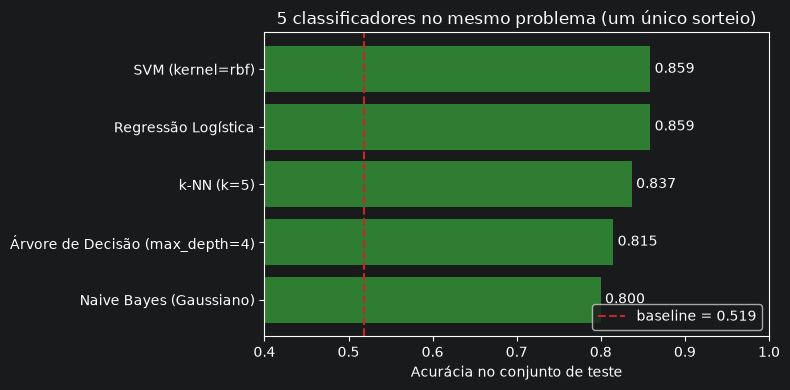

In [6]:
ordem = tabela.drop(index="Baseline (classe mais comum)").sort_values("acurácia")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ordem.index, ordem["acurácia"], color="#2e7d32")
ax.axvline(acc_base, color="#c62828", linestyle="--", label=f"baseline = {acc_base:.3f}")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("Acurácia no conjunto de teste")
ax.set_title("5 classificadores no mesmo problema (um único sorteio)")
ax.legend(loc="lower right")
for i, v in enumerate(ordem["acurácia"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

**Leitura.** Todos superam o baseline com folga — há sinal nos dados. As diferenças *entre* os modelos são pequenas. Com apenas 135 exemplos de teste, cada exemplo vale cerca de 0,7 ponto percentual: uma diferença de 1 ou 2 pontos pode ser só sorte do sorteio. Guarde essa ideia: ela volta na seção 7.

## 4. Além da acurácia: matriz de confusão, precisão e recall

Convenção: classe 1 = **aprovado** (positiva).

- **precisão** = dos que o modelo *aprovou*, quantos realmente eram bons pagadores
- **recall** = dos que *eram* bons pagadores, quantos o modelo aprovou

k-NN (k=5)                         aprovações indevidas (FP) = 12 | negações indevidas (FN) = 10
Regressão Logística                aprovações indevidas (FP) = 10 | negações indevidas (FN) =  9
Árvore de Decisão (max_depth=4)    aprovações indevidas (FP) = 11 | negações indevidas (FN) = 14
Naive Bayes (Gaussiano)            aprovações indevidas (FP) = 16 | negações indevidas (FN) = 11
SVM (kernel=rbf)                   aprovações indevidas (FP) = 11 | negações indevidas (FN) =  8


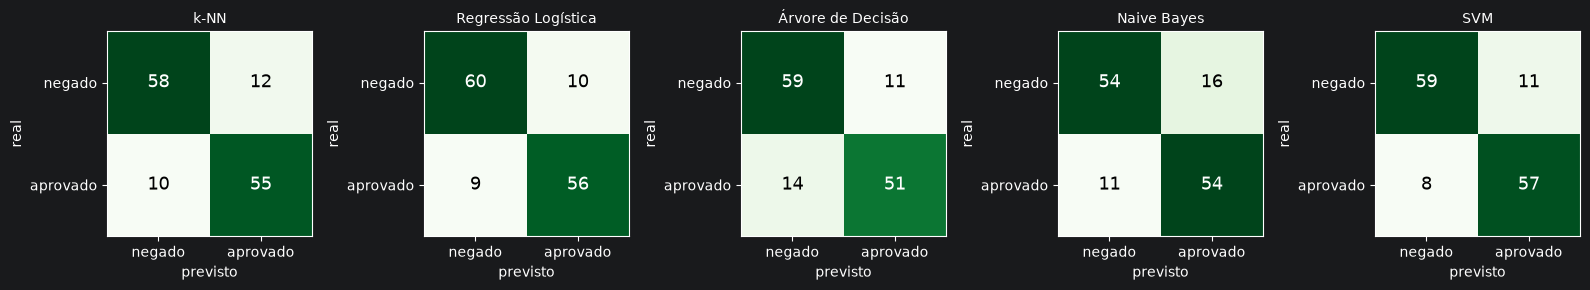

In [7]:
fig, eixos = plt.subplots(1, 5, figsize=(16, 3.3))
for ax, (nome, y_prev) in zip(eixos, predicoes.items()):
    cm = confusion_matrix(y_teste, y_prev)
    ax.imshow(cm, cmap="Greens")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["negado", "aprovado"]); ax.set_yticklabels(["negado", "aprovado"])
    ax.set_xlabel("previsto"); ax.set_ylabel("real")
    ax.set_title(nome.split(" (")[0], fontsize=10)
    tn, fp, fn, tp = cm.ravel()
    print(f"{nome:34s} aprovações indevidas (FP) = {fp:2d} | negações indevidas (FN) = {fn:2d}")
plt.tight_layout()
plt.show()

**Leitura.** Dois modelos com acurácia parecida podem errar de jeitos **diferentes**. Em crédito, os dois erros têm custos diferentes: aprovar quem não vai pagar (falso positivo) costuma custar mais que negar quem pagaria (falso negativo). Quem escolhe o modelo precisa olhar para *qual* erro importa mais.

## 5. O que a escala faz por cada modelo

Mesmo treino e teste, mas **sem** padronizar os atributos numéricos.

In [8]:
linhas = []
for nome, modelo in criar_modelos().items():
    com = resultados[nome]["acurácia"]
    pipe = Pipeline([("prep", montar_preprocessador(escalar=False)), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    sem = accuracy_score(y_teste, pipe.predict(X_teste))
    linhas.append((nome, com, sem, sem - com))
pd.DataFrame(linhas, columns=["modelo", "com_escala", "sem_escala", "diferença"]).set_index("modelo").round(3)

,com_escala,sem_escala,diferença
modelo,,,
k-NN (k=5),0.837,0.748,-0.089
Regressão Logística,0.859,0.859,0.000
Árvore de Decisão (max_depth=4),0.815,0.815,0.000
Naive Bayes (Gaussiano),0.800,0.815,0.015
SVM (kernel=rbf),0.859,0.607,-0.252


**Leitura.** k-NN e SVM dependem de **distância**: sem padronizar, `renda` (milhares) domina `idade` (dezenas) e o desempenho despenca. Regressão logística, árvore e Naive Bayes praticamente não mudam de acurácia (a árvore compara cada atributo com um limiar, que acompanha a escala). **Regra prática:** padronize sempre que o modelo usar distância.

## 6. Um hiperparâmetro em ação: simples demais × complexo demais

In [9]:
print("k-NN — variando o número de vizinhos (k):")
linhas = []
for k in [1, 3, 5, 15, 31, 71]:
    pipe = Pipeline([("prep", montar_preprocessador()), ("modelo", KNeighborsClassifier(k))]).fit(X_treino, y_treino)
    linhas.append((k, pipe.score(X_treino, y_treino), pipe.score(X_teste, y_teste)))
display(pd.DataFrame(linhas, columns=["k", "acc_treino", "acc_teste"]).round(3))

print("Árvore de decisão — variando a profundidade máxima:")
linhas = []
for d in [1, 2, 4, 8, 16, None]:
    pipe = Pipeline([("prep", montar_preprocessador()),
                     ("modelo", DecisionTreeClassifier(max_depth=d, random_state=SEMENTE))]).fit(X_treino, y_treino)
    linhas.append((str(d), pipe.score(X_treino, y_treino), pipe.score(X_teste, y_teste)))
display(pd.DataFrame(linhas, columns=["max_depth", "acc_treino", "acc_teste"]).round(3))

k-NN — variando o número de vizinhos (k):


,k,acc_treino,acc_teste
0,1,1.000,0.719
1,3,0.870,0.793
2,5,0.841,0.837
3,15,0.851,0.852
4,31,0.857,0.859
5,71,0.838,0.881


Árvore de decisão — variando a profundidade máxima:


,max_depth,acc_treino,acc_teste
0,1,0.832,0.822
1,2,0.832,0.822
2,4,0.876,0.815
3,8,0.978,0.793
4,16,1.000,0.800
5,None,1.000,0.800


**Leitura.** Com `k=1` o k-NN acerta 100% do treino (cada ponto é o próprio vizinho) mas cai no teste; a árvore sem limite também decora o treino. É o mesmo padrão da regressão polinomial de grau alto: modelo flexível demais memoriza o ruído. Repare que `k=71` tem a *melhor* acurácia de teste — mas escolher `k` olhando para o teste seria trapaça, porque o teste deixaria de ser "dado nunca visto". Como ajustar hiperparâmetros com honestidade é o tema da aula seguinte.

## 7. O problema de um único sorteio

Repetimos o experimento inteiro com 10 divisões treino/teste diferentes.

In [10]:
nomes = list(criar_modelos().keys())
acuracias = {n: [] for n in nomes}
vencedores = []
for semente in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=semente, stratify=y)
    rodada = {}
    for nome, modelo in criar_modelos().items():
        pipe = Pipeline([("prep", montar_preprocessador()), ("modelo", modelo)]).fit(X_tr, y_tr)
        rodada[nome] = pipe.score(X_te, y_te)
        acuracias[nome].append(rodada[nome])
    vencedores.append(max(rodada, key=rodada.get))

resumo = pd.DataFrame({
    "média": {n: np.mean(v) for n, v in acuracias.items()},
    "desvio": {n: np.std(v) for n, v in acuracias.items()},
    "mínimo": {n: np.min(v) for n, v in acuracias.items()},
    "máximo": {n: np.max(v) for n, v in acuracias.items()},
}).round(3)
display(resumo)
print("Quem foi o 1º colocado em cada um dos 10 sorteios:")
print(pd.Series(vencedores).value_counts().to_string())

,média,desvio,mínimo,máximo
k-NN (k=5),0.801,0.012,0.785,0.822
Regressão Logística,0.835,0.026,0.785,0.867
Árvore de Decisão (max_depth=4),0.830,0.026,0.793,0.889
Naive Bayes (Gaussiano),0.799,0.029,0.756,0.837
SVM (kernel=rbf),0.841,0.019,0.807,0.867


Quem foi o 1º colocado em cada um dos 10 sorteios:
Regressão Logística                5
SVM (kernel=rbf)                   3
Árvore de Decisão (max_depth=4)    2


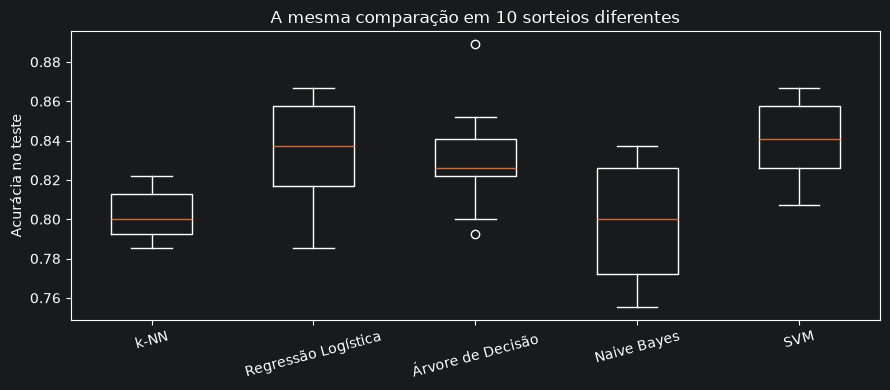

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([acuracias[n] for n in nomes])
ax.set_xticklabels([n.split(" (")[0] for n in nomes])
ax.set_ylabel("Acurácia no teste")
ax.set_title("A mesma comparação em 10 sorteios diferentes")
plt.setp(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()

**Conclusão.** Mudando só o sorteio, o "melhor modelo" muda, e as faixas de desempenho se sobrepõem bastante. Uma única divisão treino/teste é uma estimativa **ruidosa** — declarar um vencedor com base nela é arriscado. Como avaliar de forma mais confiável (validação cruzada, métricas adequadas, curvas de aprendizado) é o assunto da próxima sessão.